# Lab 6 - EDGE INTELLIGENCE ( MACSE604 ) Shruti Pandey 19th Feb ' 26

Loading video and extracting contents of frame

In [3]:
# Importing necessary libs
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Loading the pre-trained MobileNetV2 model.
model = MobileNetV2(weights='imagenet')

def extract_frames(video_path, max_frames=20):
    # This function extracts a specified number of frames from a video.
    # video_path: The file path to the input video.
    # max_frames: The maximum number of frames to extract from the video (default is 20).

    cap = cv2.VideoCapture(video_path) # Creating a VideoCapture object to read the video file.

    if not cap.isOpened(): # Checking if the video file was opened successfully.
        print("Error: Cannot open video") # Error message if the video cannot be opened.
        return np.array([]) # Returning an empty NumPy array if the video cannot be opened.

    # Retrieving video properties: width, height, and frames per second (FPS).
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) # Get the width of the video frames.
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # Get the height of the video frames.
    fps = cap.get(cv2.CAP_PROP_FPS) # Get the frames per second of the video.

    # Determining video quality based on resolution
    video_quality_description = ""
    if width >= 3840 or height >= 2160:
        video_quality_description = "4K or higher"
    elif width >= 1920 or height >= 1080:
        video_quality_description = "Full HD (1080p)"
    elif width >= 1280 or height >= 720:
        video_quality_description = "HD (720p)"
    else:
        video_quality_description = "Standard Definition (SD) or lower"

    print(f"Video Resolution: {width}x{height}, FPS: {fps}. This video is {video_quality_description}.")

    frames = [] # Initializing an empty list to store the extracted frames.
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # Getting the total number of frames in the video.

    # Calculating the step size to extract frames evenly across the video.
    step = max(1, total_frames // max_frames) if total_frames > 0 else 1 # Avoiding division by zero if total_frames is 0.
    count = 0 # Initializing a counter for the current frame being processed.

    while True: # Looping indefinitely to read frames from the video.
        ret, frame = cap.read() # to read frame .
        if not ret: # If 'ret' is False, it means there are no more frames to read, so break the loop.
            break

        if count % step == 0: # Checking if the current frame should be extracted based on the calculated step.
            frame = cv2.resize(frame, (224, 224)) # Resizing the frame
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) # Converting the frame from BGR (OpenCV's default) to RGB (TensorFlow/Keras's preferred format).
            frames.append(frame) # Adding the processed frame to the list of extracted frames.

        count += 1
        if len(frames) >= max_frames: # If we have extracted the desired number of frames, stop.
            break

    cap.release() # Release the VideoCapture object, freeing up resources.
    print("Extracted frames:", len(frames)) # Printing the total number of frames that were extracted.
    if len(frames) > 0: # Checking if any frames were actually extracted.
        print("\nShapes of all extracted frames:")
        for i, frame in enumerate(frames):
            print(f"  Frame {i+1}: {frame.shape}") # Printing the shape of each extracted frame.
    return np.array(frames)

def classify_video(video_path):
    # This function classifies the content of a video by processing its frames through a pre-trained image classification model.
    # video_path: The file path to the input video.

    frames = extract_frames(video_path) # Call the extract_frames function to get frames from the video.

    if len(frames) == 0: # Check if no frames were extracted.
        print("No frames extracted!") # Print a message if no frames are available for classification.
        return

    frames = preprocess_input(frames) # Preprocess the extracted frames
    predictions = model.predict(frames) # Using the MobileNetV2 model to make predictions on all the preprocessed frames.

    avg_pred = np.mean(predictions, axis=0) # Calculating the average prediction across all frames.
    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    for pred in top_pred[0]: # Iterate through the top 5 predictions.
        print(pred[1], ":", round(pred[2]*100, 2), "%")

    print("Final Prediction:", top_pred[0][0][1]) # Printing the final, highest-confidence prediction for the video.

# Defining the path to the video file. This path points to an uploaded sample video.
video_path = "/content/sample_data/6543595-uhd_4096_1974_30fps.mp4"
classify_video(video_path) # Call the classify_video function with the specified video path to start the classification process.

Video Resolution: 4096x1974, FPS: 29.97002997002997. This video is 4K or higher.
Extracted frames: 20

Shapes of all extracted frames:
  Frame 1: (224, 224, 3)
  Frame 2: (224, 224, 3)
  Frame 3: (224, 224, 3)
  Frame 4: (224, 224, 3)
  Frame 5: (224, 224, 3)
  Frame 6: (224, 224, 3)
  Frame 7: (224, 224, 3)
  Frame 8: (224, 224, 3)
  Frame 9: (224, 224, 3)
  Frame 10: (224, 224, 3)
  Frame 11: (224, 224, 3)
  Frame 12: (224, 224, 3)
  Frame 13: (224, 224, 3)
  Frame 14: (224, 224, 3)
  Frame 15: (224, 224, 3)
  Frame 16: (224, 224, 3)
  Frame 17: (224, 224, 3)
  Frame 18: (224, 224, 3)
  Frame 19: (224, 224, 3)
  Frame 20: (224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
tiger_cat : 47.3 %
Egyptian_cat : 16.9 %
tabby : 9.4 %
wallaby : 2.81 %
grey_fox : 1.3 %
Final Prediction: tiger_cat


Displaying frames in grid

Video Resolution: 4096x1974, FPS: 29.97002997002997. This video is 4K or higher.
Extracted frames: 20

Shapes of all extracted frames:
  Frame 1: (224, 224, 3)
  Frame 2: (224, 224, 3)
  Frame 3: (224, 224, 3)
  Frame 4: (224, 224, 3)
  Frame 5: (224, 224, 3)
  Frame 6: (224, 224, 3)
  Frame 7: (224, 224, 3)
  Frame 8: (224, 224, 3)
  Frame 9: (224, 224, 3)
  Frame 10: (224, 224, 3)
  Frame 11: (224, 224, 3)
  Frame 12: (224, 224, 3)
  Frame 13: (224, 224, 3)
  Frame 14: (224, 224, 3)
  Frame 15: (224, 224, 3)
  Frame 16: (224, 224, 3)
  Frame 17: (224, 224, 3)
  Frame 18: (224, 224, 3)
  Frame 19: (224, 224, 3)
  Frame 20: (224, 224, 3)


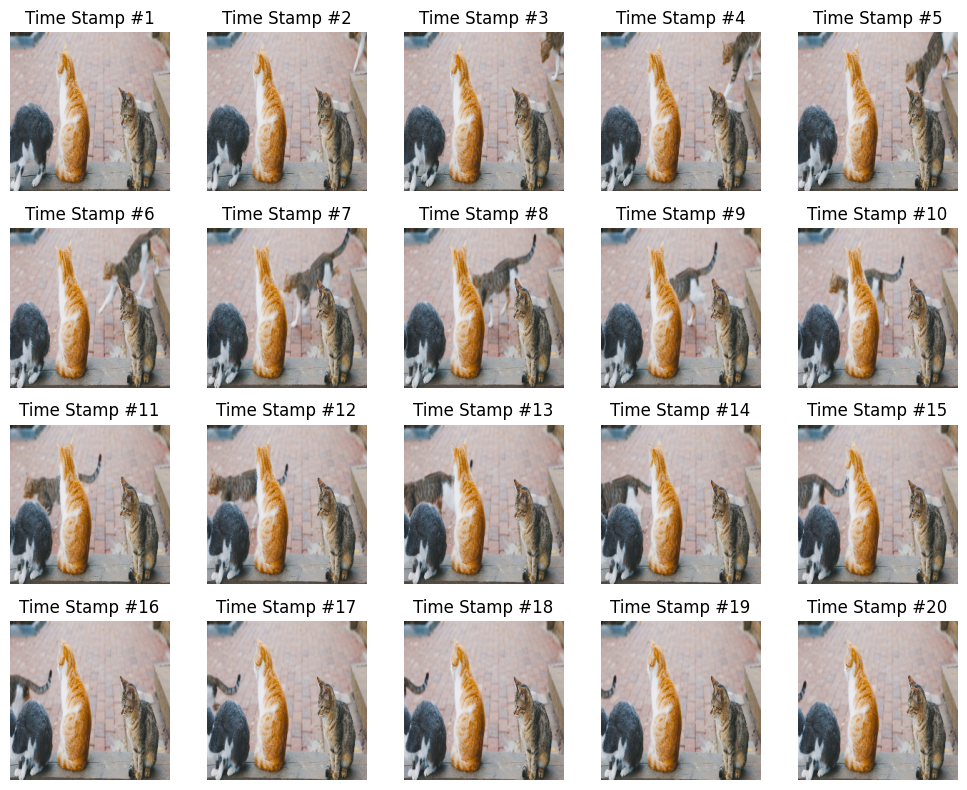

In [4]:
import matplotlib.pyplot as plt # Import module for creating plots and visuals

frames = extract_frames(video_path, 20) # Calling the 'extract_frames' function to get 20 frames

plt.figure(figsize=(10, 8)) # Creating a new figure .

# Looping through each extracted frame with its index.
for i, f in enumerate(frames):
    plt.subplot(4, 5, i+1) # Creating a subplot within the figure. This arranges plots in a 4x5 grid, and 'i+1' specifies the current plot's position.
    plt.imshow(f) # Displaying the current frame 'f' as an image in the current subplot.
    plt.title(f"Time Stamp #{i+1}") # Set the title for the current subplot, indicating the frame's index.
    plt.axis("off") # Turn off the axis labels and ticks for the current subplot to make the image cleaner.

plt.tight_layout() # Automatically adjust subplot parameters for a tight layout, preventing labels and titles from overlapping.
plt.show() # Display the figure with all the subplots.

Printing matrices

In [5]:
for i, frame in enumerate(frames):
    print(f"\nMatrix for Frame {i+1}:")
    print(frame)



Matrix for Frame 1:
[[[ 43  43  40]
  [ 58  51  44]
  [ 67  58  49]
  ...
  [153 126  94]
  [135 107  82]
  [123  97  74]]

 [[ 44  44  41]
  [ 55  48  41]
  [ 65  56  47]
  ...
  [161 131  97]
  [144 114  85]
  [124  96  73]]

 [[ 41  41  38]
  [ 51  46  39]
  [ 60  55  48]
  ...
  [164 137 105]
  [151 121  90]
  [138 108  80]]

 ...

 [[129 131 138]
  [118 116 118]
  [101 101 100]
  ...
  [121 115 116]
  [132 122 119]
  [142 134 130]]

 [[139 136 142]
  [122 118 117]
  [115 110 105]
  ...
  [ 91  85  90]
  [ 82  79  83]
  [ 78  75  81]]

 [[ 77  71  67]
  [ 85  80  77]
  [ 85  80  77]
  ...
  [ 87  85  83]
  [ 76  75  82]
  [ 63  62  69]]]

Matrix for Frame 2:
[[[ 46  44  38]
  [ 61  51  45]
  [ 65  58  51]
  ...
  [156 160 162]
  [141 143 143]
  [127 115 111]]

 [[ 45  43  39]
  [ 59  49  43]
  [ 63  56  49]
  ...
  [152 158 162]
  [138 142 144]
  [127 119 117]]

 [[ 41  41  36]
  [ 47  47  38]
  [ 58  53  46]
  ...
  [153 158 160]
  [136 145 148]
  [125 125 118]]

 ...

 [[112 112